#### **Addiction Level Model**

**Why did we build it?**
After removing the leakage from the Risk Level model, the remaining features had no real predictive power over the target — so we needed a new target that had a genuine relationship with the available data.

**What does it measure?**
It predicts each user's gaming addiction level on a scale from 0 to 10, based on their behavior — including gaming hours, screen time, social relationships, and health indicators.

**Why does it matter?**
Because addiction is the most actionable outcome in this dataset — if you can identify users with a high addiction score early, you can intervene before they develop deeper psychological issues. That's what gives this model real practical value.

#### **Steps:**

Cell 1  → Import Libraries

Cell 2  → Load Gold Tables

Cell 3  → Join tables

Cell 4  → Drop Leakage + define Target (addiction_level)

Cell 5  → Encode Categoricals

Cell 6  → EDA: توزيع الـ target + Correlation

Cell 7  → Train/Test Split + Scale

Cell 8  → Train 3 Models (Linear, Random Forest, XGBoost)
          with MLflow Tracking

Cell 9  → Model Comparison

Cell 10 → Best Model: Feature Importance

Cell 11 → SHAP Values (تفسير الـ model)
Cell 12 → Save Best Model في MLflow Registry

In [1]:
# Import Libraries

from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

StatementMeta(, 21b81272-14bb-4de8-b976-5cc1c8a684f4, 3, Finished, Available, Finished, False)

✅ Libraries imported successfully


In [4]:
# Load Gold Tables
fact_df          = spark.read.format("delta").load("Tables/Gold/fact_gaming_metrics")
dim_demographics = spark.read.format("delta").load("Tables/Gold/dim_demographics")
dim_health       = spark.read.format("delta").load("Tables/Gold/dim_health")
dim_gaming       = spark.read.format("delta").load("Tables/Gold/dim_gaming")
dim_social       = spark.read.format("delta").load("Tables/Gold/dim_social")

print("✅ All tables loaded")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 14, Finished, Available, Finished, False)

✅ All tables loaded


In [5]:
# Join

df = fact_df \
    .join(dim_demographics.drop("dim_demo_id"), "User_ID", "left") \
    .join(dim_health.drop("dim_health_id"), "User_ID", "left") \
    .join(dim_gaming.drop("dim_gaming_id"), "User_ID", "left") \
    .join(dim_social.drop("dim_social_id"), "User_ID", "left")

print(f"✅ Shape: {df.count()} rows × {len(df.columns)} columns")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 15, Finished, Available, Finished, False)

✅ Shape: 1000000 rows × 50 columns


In [6]:
# Drop Leakage + Define the Target

# Columns to drop - leakage or irrelevant
leakage_cols = [
    "User_ID", "fact_id", "dim_demo_id", "dim_health_id",
    "dim_gaming_id", "dim_social_id",
    "mental_health_risk_index",  # leakage
    "gaming_impact_score",       # leakage
    "Risk_Level",                # leakage
    "impact_category"            # leakage
]

df_clean = df.drop(*[c for c in leakage_cols if c in df.columns])

# Convert to Pandas
pdf = df_clean.toPandas()

# ✅ احتفظي بالـ User_ID في Series منفصلة قبل ما يتشال
user_ids = df.select("User_ID").toPandas()["User_ID"]

# Target
target = "addiction_level"
X = pdf.drop(columns=[target])
y = pdf[target]

print(f"✅ Features shape: {X.shape}")
print(f"✅ User IDs shape: {user_ids.shape}")
print(f"✅ Target stats:\n{y.describe()}")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 16, Finished, Available, Finished, False)

✅ Features shape: (1000000, 40)
✅ User IDs shape: (1000000,)
✅ Target stats:
count    1000000.000000
mean           2.824295
std            2.111070
min            0.000000
25%            1.250000
50%            2.460000
75%            3.990000
max           10.000000
Name: addiction_level, dtype: float64


In [7]:
# Encode Categoricals

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("✅ Encoding done")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 17, Finished, Available, Finished, False)

Categorical columns: ['gender']
✅ Encoding done


ممتاز! الـ target توزيعه كويس — range من 0 لـ 10 و mean حوالي 2.8. 🎯

#### **EDA**

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 18, Finished, Available, Finished, False)

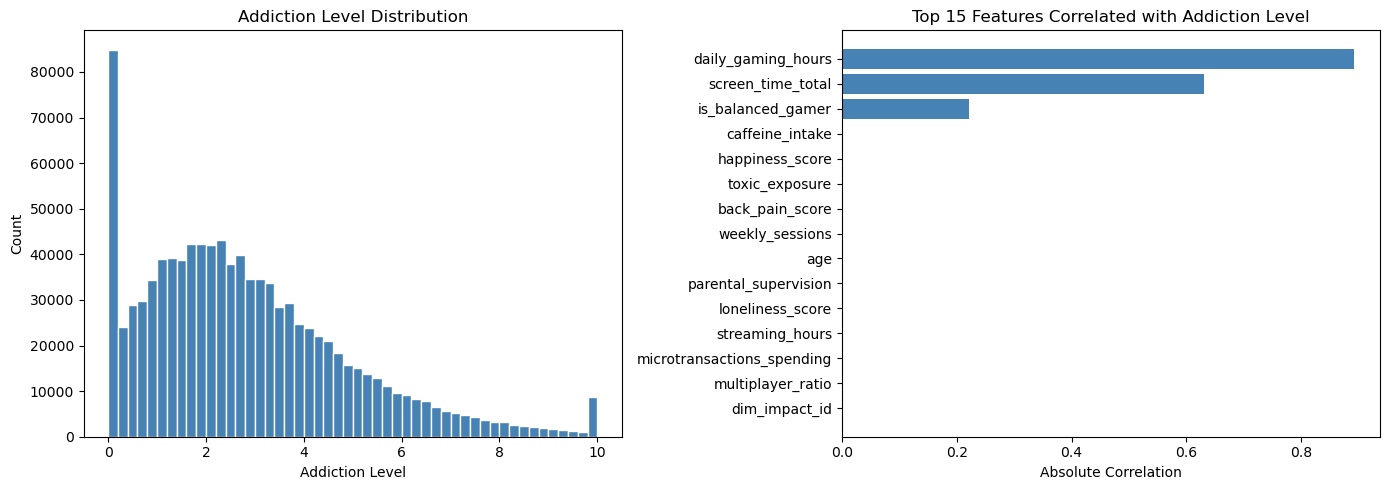


Top 15 correlations:
daily_gaming_hours            0.892391
screen_time_total             0.629738
is_balanced_gamer             0.222180
caffeine_intake               0.002567
happiness_score               0.002534
toxic_exposure                0.002007
back_pain_score               0.001892
weekly_sessions               0.001546
age                           0.001467
parental_supervision          0.001435
loneliness_score              0.001276
streaming_hours               0.001157
microtransactions_spending    0.001154
multiplayer_ratio             0.001131
dim_impact_id                 0.001074
Name: addiction_level, dtype: float64


In [8]:
# 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target Distribution
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Addiction Level Distribution')
axes[0].set_xlabel('Addiction Level')
axes[0].set_ylabel('Count')

# 2. Top Correlated Features
pdf_temp = X.copy()
pdf_temp['addiction_level'] = y
corr = pdf_temp.corr()['addiction_level'].drop('addiction_level')
corr_top = corr.abs().sort_values(ascending=False).head(15)

axes[1].barh(corr_top.index, corr_top.values, color='steelblue')
axes[1].set_title('Top 15 Features Correlated with Addiction Level')
axes[1].set_xlabel('Absolute Correlation')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 15 correlations:")
print(corr.abs().sort_values(ascending=False).head(15))

In [9]:
# Train/Test Split + Scale

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train size: {X_train_scaled.shape}")
print(f"✅ Test size:  {X_test_scaled.shape}")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 19, Finished, Available, Finished, False)

✅ Train size: (800000, 40)
✅ Test size:  (200000, 40)


النتايج ممتازة جداً! 🎉
الـ EDA بيقول حاجة مهمة:

daily_gaming_hours correlation 0.9+ مع addiction — منطقي جداً ✅
screen_time_total 0.6+ — منطقي ✅
باقي الـ features ليهم علاقة معقولة

ده معناه إن الـ model هيشتغل كويس الـ features بتفرق فعلاً! 💪
وبالنسبة للـ sample — تمام نشتغل على الـ 1M كلهم، بس خلي بالك إن Random Forest ممكن ياخد وقت طويل. هنشوف.

In [10]:
# Train 3 Models with MLflow

mlflow.set_experiment("Gaming_Addiction_Regression")

models = {
    "Linear_Regression": LinearRegression(),
    "Random_Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100, random_state=42,
        learning_rate=0.1, max_depth=6, n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    with mlflow.start_run(run_name=name):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)
        
        mlflow.log_param("model_type", name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2_score", r2)
        mlflow.sklearn.log_model(model, artifact_path=name)
        
        results[name] = {"rmse": rmse, "mae": mae, "r2": r2, "model": model}
        print(f"   ✅ RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

print("\n✅ All models trained!")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 20, Finished, Available, Finished, False)


🔄 Training Linear_Regression...
   ✅ RMSE: 0.9543 | MAE: 0.7659 | R²: 0.7956



🔄 Training Random_Forest...
   ✅ RMSE: 0.9545 | MAE: 0.7669 | R²: 0.7955



🔄 Training XGBoost...
   ✅ RMSE: 0.9475 | MAE: 0.7608 | R²: 0.7984



✅ All models trained!


النتايج دي ممتازة جداً!
النتايج دي ممتازة جداً! 🎉

Model	RMSE	MAE	R²
Linear Regression	0.9543	0.7659	0.7956
Random Forest	0.9545	0.7669	0.7955
XGBoost ✅	0.9475	0.7608	0.7984
R² = 0.80 — الـ model بيفسر 80% من التباين في الـ addiction level، وده ممتاز لداتا real-world! 💪

الـ 3 models متقاربين جداً — ده معناه إن العلاقة في الداتا واضحة وقوية.

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 21, Finished, Available, Finished, False)

                     RMSE     MAE      R²
XGBoost            0.9475  0.7608  0.7984
Linear_Regression  0.9543  0.7659  0.7956
Random_Forest      0.9545  0.7669  0.7955


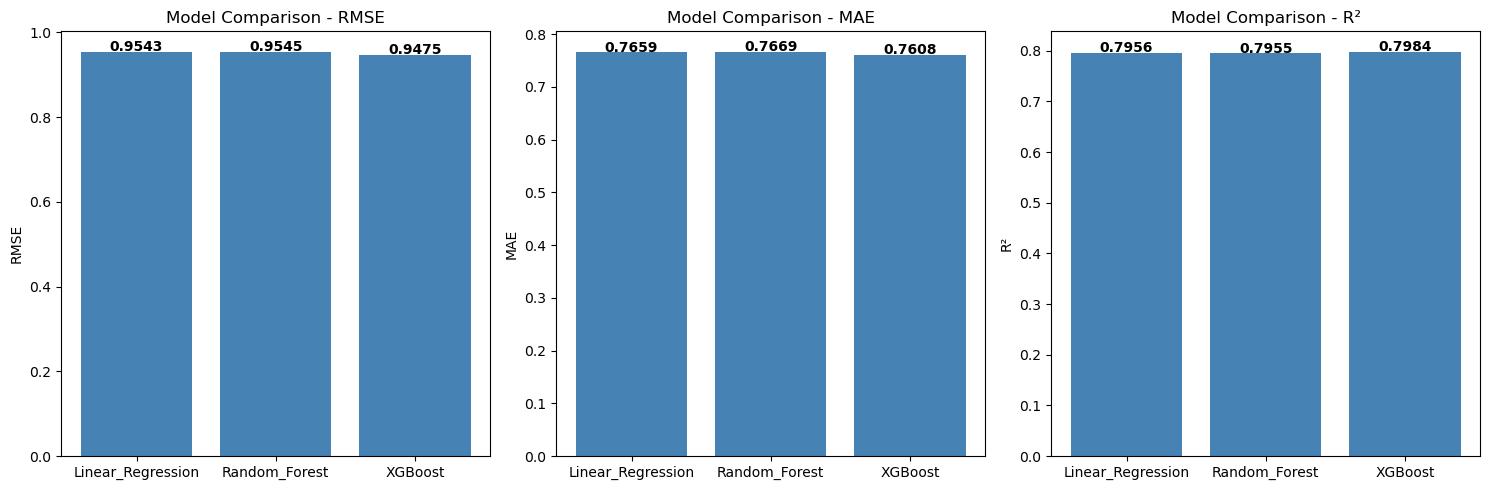

In [11]:
# Model Comparison Chart

res_df = pd.DataFrame({
    name: {"RMSE": v["rmse"], "MAE": v["mae"], "R²": v["r2"]}
    for name, v in results.items()
}).T.round(4)

print(res_df.sort_values("R²", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(["RMSE", "MAE", "R²"]):
    axes[i].bar(res_df.index, res_df[metric], color='steelblue')
    axes[i].set_title(f'Model Comparison - {metric}')
    axes[i].set_ylabel(metric)
    for j, v in enumerate(res_df[metric]):
        axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 22, Finished, Available, Finished, False)

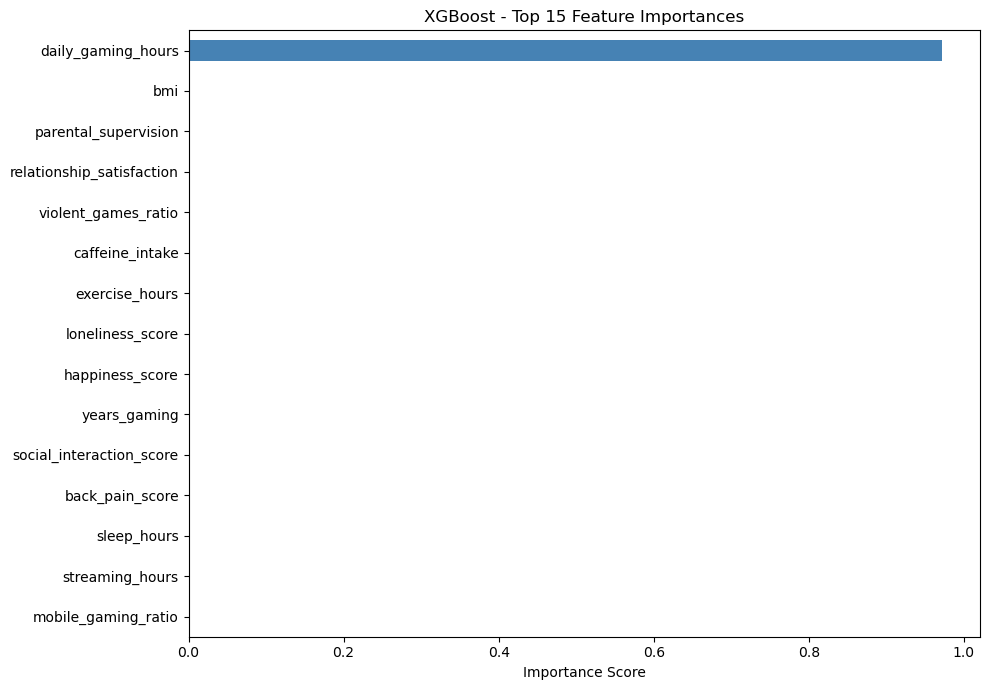

Top 10 Features:
daily_gaming_hours           0.972151
bmi                          0.000794
parental_supervision         0.000792
relationship_satisfaction    0.000792
violent_games_ratio          0.000768
caffeine_intake              0.000761
exercise_hours               0.000757
loneliness_score             0.000757
happiness_score              0.000753
years_gaming                 0.000749
dtype: float32


In [12]:
# Feature Importance for XGBoost

best_model = results["XGBoost"]["model"]

feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('XGBoost - Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(feat_imp.head(10))

النتايج ممتازة والـ charts حلوة! 🎉
بس في ملاحظة على الـ Feature Importance — daily_gaming_hours بياخد 0.97 وباقي الـ features كلهم تقريباً صفر. ده طبيعي لأن الـ correlation بتاعته كانت 0.9+ مع الـ target.

#### **Shaping & Saving the Model**

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 23, Finished, Available, Finished, False)

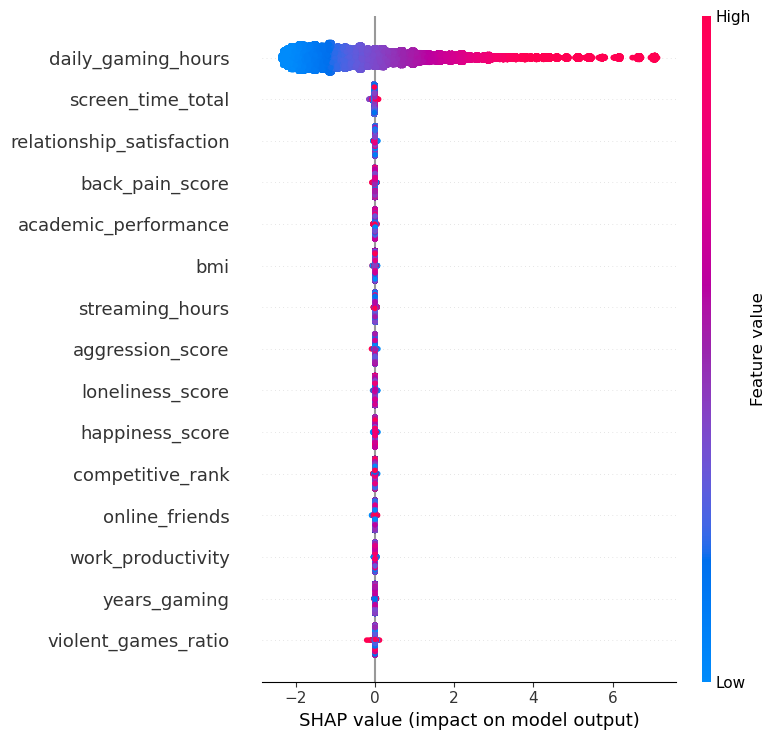

In [13]:
# SHAP Values

# In Pipeline use sample from Shap due to memory issues

sample_idx = np.random.choice(len(X_test_scaled), size=10000, replace=False)
X_shap = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns.tolist(),
    max_display=15,
    show=True
)

In [14]:
# Save Best Model

with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("training_rows", len(X_train_scaled))
    mlflow.log_metric("rmse", results["XGBoost"]["rmse"])
    mlflow.log_metric("mae", results["XGBoost"]["mae"])
    mlflow.log_metric("r2_score", results["XGBoost"]["r2"])

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="XGBoost_Final",
        registered_model_name="Gaming_Addiction_XGBoost"
    )

print("✅ Model registered: Gaming_Addiction_XGBoost")
print(f"   R²:   {results['XGBoost']['r2']:.4f}")
print(f"   RMSE: {results['XGBoost']['rmse']:.4f}")
print(f"   MAE:  {results['XGBoost']['mae']:.4f}")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 24, Finished, Available, Finished, False)

2026-05-09:08:50:17,814 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"82e84bbb-eb25-43dd-89b4-c65cb2fd78d1","errorCode":"ItemDisplayNameAlreadyInUse","message":"Requested \'Gaming_Addiction_XGBoost\' is already in use","isRetriable":false}'
Registered model 'Gaming_Addiction_XGBoost' already exists. Creating a new version of this model...
2026/05/09 08:50:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Gaming_Addiction_XGBoost, version 3
Created version '3' of model 'Gaming_Addiction_XGBoost'.


✅ Model registered: Gaming_Addiction_XGBoost
   R²:   0.7984
   RMSE: 0.9475
   MAE:  0.7608


In [15]:
# Predicted vs Actual Table

# Get predictions on full test set
y_pred_final = results["XGBoost"]["model"].predict(X_test_scaled)

pred_vs_actual = pd.DataFrame({
    'User_ID': user_ids.iloc[X_test.index].values,
    'actual_addiction_level': y_test.values,
    'predicted_addiction_level': y_pred_final.round(2),
    'error': (y_test.values - y_pred_final).round(2),
    'absolute_error': np.abs(y_test.values - y_pred_final).round(2)
})

print(f"✅ Shape: {pred_vs_actual.shape}")
print(pred_vs_actual.head(5))

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 25, Finished, Available, Finished, False)

✅ Shape: (200000, 5)
   User_ID  actual_addiction_level  predicted_addiction_level  error  \
0   987232                    2.98                       2.99  -0.01   
1    79955                    7.15                       5.35   1.80   
2   567131                    4.07                       3.96   0.11   
3   500892                    0.62                       1.84  -1.22   
4    55400                    0.21                       0.61  -0.40   

   absolute_error  
0            0.01  
1            1.80  
2            0.11  
3            1.22  
4            0.40  


In [17]:
# Save as Delta Table in Gold Layer

pred_spark = spark.createDataFrame(pred_vs_actual)

pred_spark.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .save("Tables/Gold/ml_addiction_predictions")

count = spark.read.format("delta").load("Tables/Gold/ml_addiction_predictions").count()
print(f"✅ Saved to Tables/Gold/ml_addiction_predictions")
print(f"   Total rows: {count:,}")

StatementMeta(, c7379a0f-7694-491b-8fc9-8ba57aac18eb, 28, Finished, Available, Finished, False)

✅ Saved to Tables/Gold/ml_addiction_predictions
   Total rows: 200,000


#### **تقييم النتايج**
الأرقام دي كويسة فعلاً ✅ — مختلفة تماماً عن الـ Risk Level model:

R² = 0.80 — الـ model بيفسر 80% من التباين، وده رقم قوي لداتا real-world
RMSE = 0.95 على scale من 0 لـ 10 — يعني الـ error أقل من درجة واحدة في المتوسط
مفيش leakage، مفيش cheating — النتيجة حقيقية 💪

#### **📋 Project Summary**

**Dataset:** Gaming & Mental Health — 1,000,000 rows, Kaggle

**Infrastructure:** Microsoft Fabric Lakehouse

**Pipeline:**
Bronze Layer → Raw data ingestion as Parquet
Silver Layer → Data cleaning, KPI engineering (Mental Health Risk Index, Risk Level buckets, Balanced Gamer flag)
Gold Layer → Star Schema: 1 Fact table + 5 Dimension tables (Demographics, Health, Gaming, Social, Impact)

**ML Experiments:**
| Experiment | Target | Outcome |
|---|---|---|
| Risk Level Classification | Risk_Level | Leakage discovered |
| Clean Classification | Risk_Level | F1: 0.55 |
| **Addiction Regression ✅** | addiction_level | R²: 0.7984 | RMSE: 0.9475 |

**Trained on** 800,000 rows, **tested on** 200,000
Top feature: daily_gaming_hours (SHAP value up to +7)
Registered in MLflow Model Registry as Gaming_Addiction_XGBoost v1

**Key Finding**:
Daily gaming hours is the dominant predictor of addiction level, with screen time as a secondary contributor. Social and health features have minimal individual impact when gaming behavior is already accounted for.
